##### Dimensionality Reduction Methods

#### Data Preparation - MNIST dataset

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================
# Load MNIST Dataset
# ==============================
mnist = fetch_openml('mnist_784', version=1)
# features(images)
X = mnist.data.astype(np.float32)
# labels (only for visualization)
y = mnist.target.astype(int)

print("MNIST X:", X.shape)
print("MNIST y:", y.shape)

# ================================
# Normalize and Preprocessing data
# ================================
"""
Principal Component Analysis (PCA):
Because PCA is based on variance, it is highly sensitive to the scale of the input 
features - features with larger numerical ranges can dominate the results and bias 
the principal components. Standardizing the data so that each feature has mean 0 
and standard deviation 1 ensures that all features contribute equally to the analysis,
preventing any single feature from disproportionately influencing the outcome. This
leads to more meaningful components and better representation of the underlying 
structure in the data. 
"""
scaler = StandardScaler()
X_pca = scaler.fit_transform(X)


"""
t-Distributed Stochastic Neighbor Embedding (t-SNE):
t-SNE computes pairwise similarities based on distances and converts them into 
probability distributions. Pixel values in MNIST range from 0 to 255. Without normalization, features with larger numeric scales would 
dominate the distance computation, leading to distored similarity relationships. By 
scaling values to the range[0,1], all pixels contribute more evenly, making the 
computed similarities more meaningful. This helps t-SNE better capture the true structure
of the data, resulting in clearer clusters of similar digits in the final 2D visualization. 
"""
X_tsne = X / 255.0


"""
Auto-Encoder(Neural Network-Based):
Neural networks are sensitive to the scale of input values. By scaling the data to the 
range [0,1], the inputs align well with common activation functions like sigmoid or ReLU,
improving numerical stability and helping the network converge faster. Moreover, when
using a sigmoid outout layer, normalized inputs ensure that both the input and output
are on the same scale, leading to more accurate reconstructions.
"""
X_ae = X / 255.0

MNIST X: (70000, 784)
MNIST y: (70000,)


#### Dimensionality Reduction

In [2]:
# ==================================
# Principal Component Analysis (PCA)
# ==================================
from sklearn.decomposition import PCA

"""
Reduce high-dimensional data to 2D.

PCA finds directions(principal components) with maximum variance, and it
projects data onto the top 2 eigenvectors, capturing the most important
structure of the data.
"""
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_pca)

print("PCA 2D output shape:", X_pca_2d.shape)


# ===================================================
# t-Distributed Stochastic Neighbor Embedding (t-SNE)
# ===================================================
from sklearn.manifold import TSNE

"""
t-SNE computes pairwirse similarities between all points(O(n^2)), so using the full
70,000 images in MNIST would require billions of pairwise computations, making
it extremely slow and memoery-intensive. So a smaller subset is selected to 
reduce computation time while still preserving the overall structure and pattern
of the data. This works because MNIST contains many redundant examples of similar
digits. 
"""
X_subset = X_tsne[:20000]
y_subset = y[:20000]

"""
TSNE parameters:
n_component: output dimension.
perplexity: controls how many neighbors each point considers; 
            small perplexity -> focus on very local structure;
            lage perplexity -> consider more global structure.
learning_rate: step size during optimization.
max_iter: number of optimization steps; more iterations, better convergence, but slower.
random_state: make results reproducible.
init: t-SNE uses gradient descent, which means it starts somewhere, then gradually
      moves points to better positions. Init controls how the points are placed at 
      the start of the optimization. The starting point(init) can affect the speed 
      of convergence and stability. PCA result is used as starting position because
      it already has some structure.     
"""
tsne = TSNE(n_components=2, 
            perplexity=30, 
            learning_rate=200, 
            max_iter=1000,
            random_state=42,
            init='pca',
            )
X_tsne_2d = tsne.fit_transform(X_subset)
print("t-SNE 2D output shape:", X_tsne_2d.shape)


#===================================
# Auto-Encoder (Neural Network-Based)
#===================================
from tensorflow.keras.models import Model # Model is used to define neural network models in Keras
"""Input: used to define the input layer
   Dense: a fully connected neural network layer -> every neuron in this layer is connected to 
          every neuron in the previous layer.
          It performs a transformation like:
            output = activation(W x + b)
            x: input vector
            W: weights(learned during training)
            b: bias
            activation: relu, sigmoid
"""        
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# Input layer: each MNIST image is originally 28 * 28 = 784 pixels; flatten into 1D vector of size 784
input_img = Input(shape=(784,))

# Encoder (gradually compress the input into 2D latent representation)
encoded = Dense(128, activation='relu')(input_img) # reduce 784 to 128 dimensions; relu helps learn nonlinear patterns
encoded = Dense(64, activation='relu')(encoded) # further compresses from 128 to 64 dimensions
latent = Dense(2, activation='linear')(encoded)  # further compresses from 64 to 2 dimensions -> 2D representation
# activation function is linear because no extra nonlinear transformation is applied at this layer.

# Decoder (reconstruct the original image from the 2D latent space)
decoded = Dense(64, activation='relu')(latent) # expand from 2 to 64
decoded = Dense(128, activation='relu')(decoded) # expand from 64 to 128
output = Dense(784, activation='sigmoid')(decoded) # expand from 128 to 784; sigmoid outputs values in [0,1]
# sigmoid is used in the output layer becasue MNIST pixel values are normalized to [0,1], and signmoid
# ensures the reconstructed output stays in the same valid range(sigmoid maps any real number to (0,1)), making 
# training stable and consistent with the loss function - binary_crossentropy(outputs are probabilities(0,1)).

# full autoencoder model: input(784) -> encoder -> latent(2D) -> decoder -> reconstructed output(784)
autoencoder = Model(inputs=input_img, outputs=output)

# encoder model only: input(784) -> 2D latent representation
encoder = Model(inputs=input_img, outputs=latent)  # Extract 2D features

# prepare autoencoder for training
# adam: optimization algorithm used to update weights during training
# binary_crossentropy: measures the differences between the reconstructed output and the original input.
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

# Train the model
autoencoder.fit(X_ae, X_ae, # input and target are the same because autoencoder tries to reconstruct its own input
                epochs=10, # model goes through dataset 10 times
                batch_size=256, #model trains on 256 images at a time
                shuffle=True # shuffles the training data before each epoch so the model does not learn from a fixed order
                )

# Get 2D representation
X_ae_2d = encoder.predict(X_ae)

print("2D latent representation shape:", X_ae_2d.shape)

PCA 2D output shape: (70000, 2)
t-SNE 2D output shape: (20000, 2)


2026-04-02 14:35:59.810930: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.2682
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2208
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2045
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1977
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1926
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1889
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1865
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1847
Epoch 9/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1832
Epoch 10/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1820
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 2s 756us/step
2D latent representation shape: (70000, 2)


#### Visualization

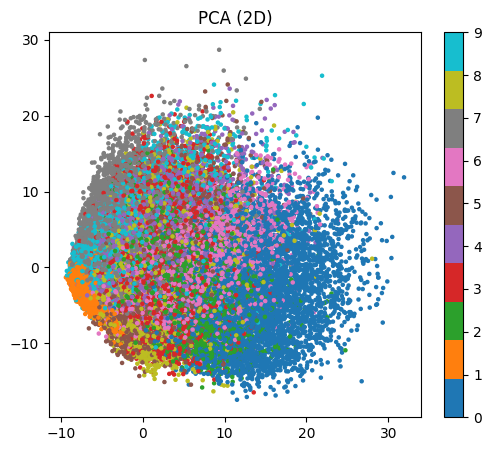

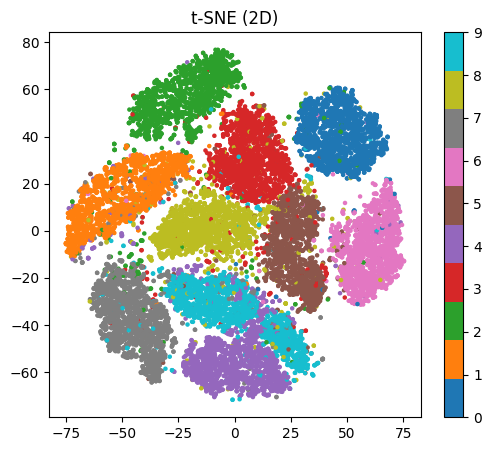

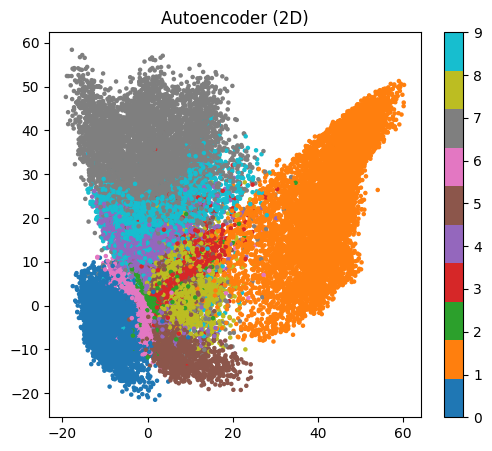

In [3]:
import matplotlib.pyplot as plt

# X_2d[:,0]: x-axis(first dimension)
# X_2d[:,1]: y-axis(second dimension)
# c=y: color points based on labels(0-9)
# cmap='tab10': 10 distinct colors
# s: size of dots
def plot_2d(X_2d, y, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X_2d[:,0], X_2d[:,1], c=y, cmap='tab10', s=5)
    plt.title(title)
    plt.colorbar()
    plt.show()

# PCA
plot_2d(X_pca_2d, y, "PCA (2D)")

# t-SNE
plot_2d(X_tsne_2d, y_subset, "t-SNE (2D)")

# Autoencoder
plot_2d(X_ae_2d, y, "Autoencoder (2D)")

##### Confusion Matrix
1. compute class prototypes as mean positions in the 2D embedding space;
2. assign each sample to the nearest prototype using Euclidean distance;
3. evaluate the quality of the representation using a confusion matrix. 

PCA Accuracy: 0.3300


<Figure size 800x800 with 0 Axes>

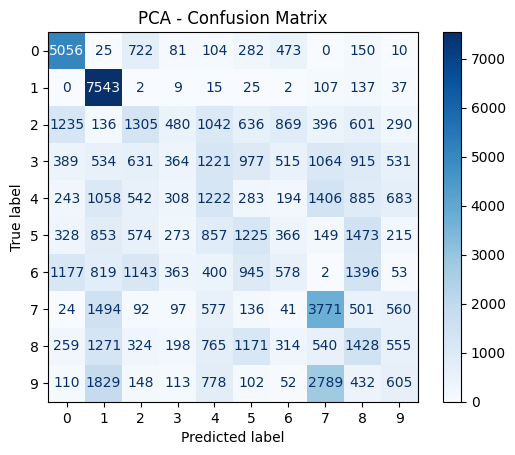

t-SNE Accuracy: 0.8894


<Figure size 800x800 with 0 Axes>

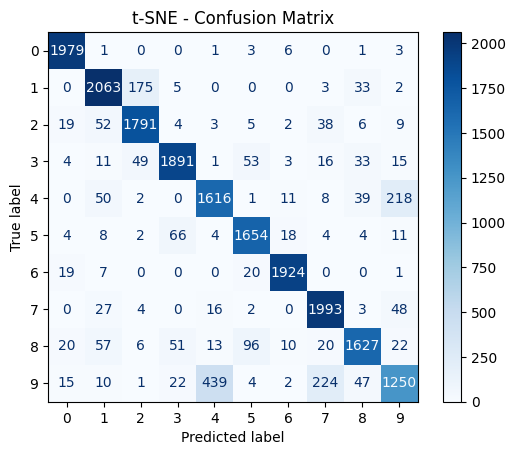

Autoencoder Accuracy: 0.6291


<Figure size 800x800 with 0 Axes>

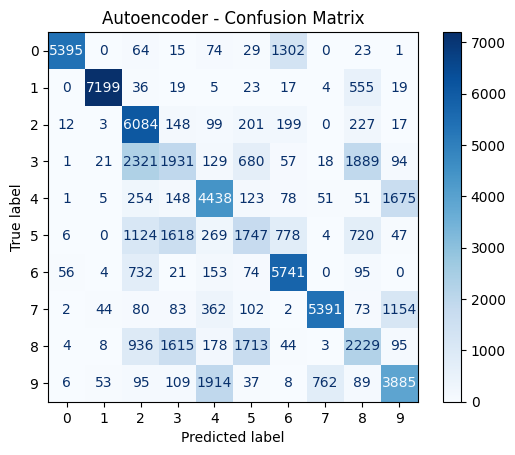

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.spatial.distance import cdist

def build_prototypes(X_2d, y):
    """
    Compute one prototype (mean point) for each digit class 0-9.
    Returns a dictionary:
        prototypes[digit] = mean 2D coordinate of that digit
    """
    prototypes = {}
    for digit in range(10):
        prototypes[digit] = X_2d[y == digit].mean(axis=0) # select all samples of that digit, compute mean of their 2D coordinates
    return prototypes # return a dictionary where each key is a digit and the value is the mean 2D coordinate of that digit

def predict(X_2d, prototypes):
    """
    For each sample, compute distance to all 10 prototypes
    and assign the label of the closest prototype.
    """
    proto_array = np.array([prototypes[d] for d in range(10)])   # convert dictionary to array; shape (10, 2)
    distances = cdist(X_2d, proto_array)   # compute distance from every sample to every prototype; shape (n_samples, 10)
    return np.argmin(distances, axis=1)    # for each sample, find the closest prototype -> predicted digit; shape (n_samples,)      

def evaluate_representation(X_2d, y, name):
    prototypes = build_prototypes(X_2d, y)
    y_pred = predict(X_2d, prototypes)

    cm = confusion_matrix(y, y_pred)
    acc = np.mean(y == y_pred) # accuracy = number of correct predictions / total number of samples

    print(f"{name} Accuracy: {acc:.4f}")

    plt.figure(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    return prototypes, y_pred, cm, acc

pca_prototypes, y_pred_pca, cm_pca, acc_pca = evaluate_representation(X_pca_2d, y, "PCA")
tsne_prototypes, y_pred_tsne, cm_tsne, acc_tsne = evaluate_representation(X_tsne_2d, y_subset, "t-SNE")
ae_prototypes, y_pred_ae, cm_ae, acc_ae = evaluate_representation(X_ae_2d, y, "Autoencoder")